# DSN Mart Sales Prediction — DSN AI Bootcamp Qualifying Hackathon (ML Track)

**Goal:** Predict `total_sales` for a given product at a given store (regression, evaluated by RMSE).

**Workflow:** Understand → Analyse → Model → Predict → Communicate

**Author:** Adepoju


## 1. Understand — Load data and get oriented

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor
import lightgbm as lgb

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print('train shape:', train.shape)
print('test shape :', test.shape)
train.head()


train shape: (6818, 13)
test shape : (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


In [4]:
print('Missing values (train):')
print(train.isna().sum())
print()
print('Missing values (test):')
print(test.isna().sum())


Missing values (train):
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Missing values (test):
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


**Observations so far**

- `train` has 6,818 rows / 13 columns, `test` has 1,705 rows / 12 columns (no `total_sales`) — together they cover 8,523 unique product-store records.
- `product_weight_kg` and `store_size` have missing values in both train and test — these need imputation.
- `total_sales` is the regression target.


## 2. Analyse — Exploratory Data Analysis

In [5]:
train.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6818,6818,row_00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_code,6818,1555,PRD-YZB4K8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,5593.0,NaN,NaN,NaN,12.850876,4.646542,4.482,8.75,12.647,16.894,21.883
fat_content,6818,2,Low Fat,4425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_visibility,6818.0,NaN,NaN,NaN,0.065527,0.051566,0.0,0.0266,0.0532,0.0934,0.3201
product_category,6818,48,Fruits and Vegetables,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_price,6818.0,NaN,NaN,NaN,140.473623,62.413513,31.11,93.28,142.065,185.9875,273.04
store_code,6818,10,STORE-YLW,754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_age_years,6818.0,NaN,NaN,NaN,34.178205,8.384574,23.0,28.0,33.0,45.0,47.0
store_size,4899,3,Medium,2218,NaN,NaN,NaN,NaN,NaN,NaN,NaN


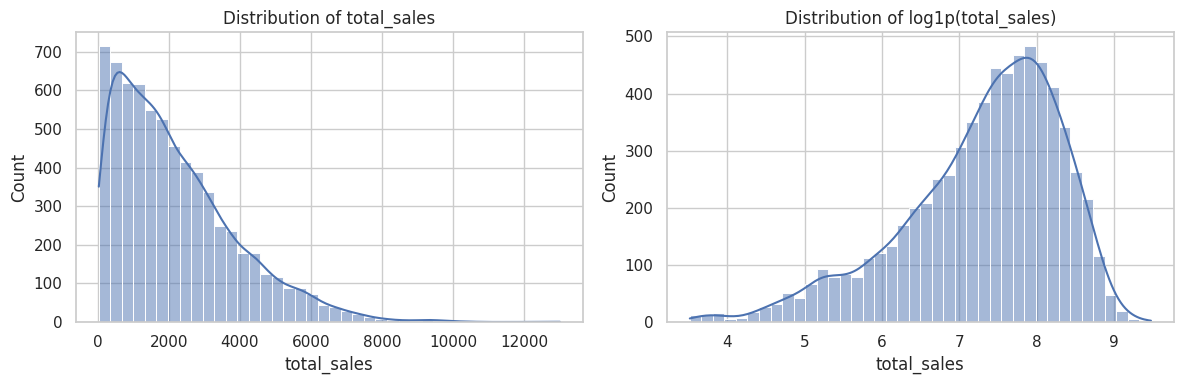

Skew (raw): 1.154
Skew (log1p): -0.895


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['total_sales'], bins=40, kde=True, ax=ax[0])
ax[0].set_title('Distribution of total_sales')
sns.histplot(np.log1p(train['total_sales']), bins=40, kde=True, ax=ax[1])
ax[1].set_title('Distribution of log1p(total_sales)')
plt.tight_layout()
plt.show()

print('Skew (raw):', train['total_sales'].skew().round(3))
print('Skew (log1p):', np.log1p(train['total_sales']).skew().round(3))


`total_sales` is right-skewed, as expected for retail sales data. We'll test both raw and transformed targets during modelling and keep whichever gives the lower cross-validated RMSE.

In [7]:
# product_category has messy, inconsistent casing - a data quality issue to fix
print('Raw unique product_category values:', train['product_category'].nunique())
sorted(train['product_category'].unique())


Raw unique product_category values: 48


['BAKING GOODS',
 'BREADS',
 'BREAKFAST',
 'Baking Goods',
 'Breads',
 'Breakfast',
 'CANNED',
 'Canned',
 'DAIRY',
 'Dairy',
 'FROZEN FOODS',
 'FRUITS AND VEGETABLES',
 'Frozen Foods',
 'Fruits and Vegetables',
 'HARD DRINKS',
 'HEALTH AND HYGIENE',
 'HOUSEHOLD',
 'Hard Drinks',
 'Health and Hygiene',
 'Household',
 'MEAT',
 'Meat',
 'OTHERS',
 'Others',
 'SEAFOOD',
 'SNACK FOODS',
 'SOFT DRINKS',
 'STARCHY FOODS',
 'Seafood',
 'Snack Foods',
 'Soft Drinks',
 'Starchy Foods',
 'baking goods',
 'breads',
 'breakfast',
 'canned',
 'dairy',
 'frozen foods',
 'fruits and vegetables',
 'hard drinks',
 'health and hygiene',
 'household',
 'meat',
 'others',
 'seafood',
 'snack foods',
 'soft drinks',
 'starchy foods']

In [8]:
# Normalise casing and re-check
_tmp = train['product_category'].str.strip().str.lower()
print('Unique categories after lowercasing:', _tmp.nunique())
sorted(_tmp.unique())


Unique categories after lowercasing: 16


['baking goods',
 'breads',
 'breakfast',
 'canned',
 'dairy',
 'frozen foods',
 'fruits and vegetables',
 'hard drinks',
 'health and hygiene',
 'household',
 'meat',
 'others',
 'seafood',
 'snack foods',
 'soft drinks',
 'starchy foods']

Once we lowercase and strip whitespace, `product_category` collapses from 48 noisy labels down to the true **16 categories**. `fat_content` (`Low Fat` / `Regular`) is already clean.

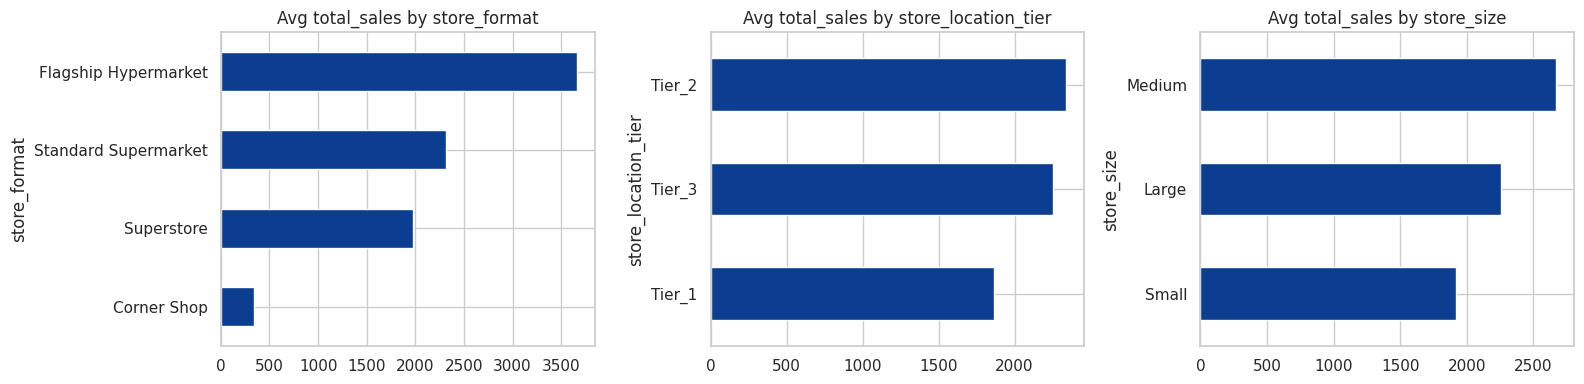

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
train.groupby('store_format')['total_sales'].mean().sort_values().plot(kind='barh', ax=ax[0], color='#0B3D91')
ax[0].set_title('Avg total_sales by store_format')
train.groupby('store_location_tier')['total_sales'].mean().sort_values().plot(kind='barh', ax=ax[1], color='#0B3D91')
ax[1].set_title('Avg total_sales by store_location_tier')
train.groupby('store_size')['total_sales'].mean().sort_values().plot(kind='barh', ax=ax[2], color='#0B3D91')
ax[2].set_title('Avg total_sales by store_size')
plt.tight_layout()
plt.show()


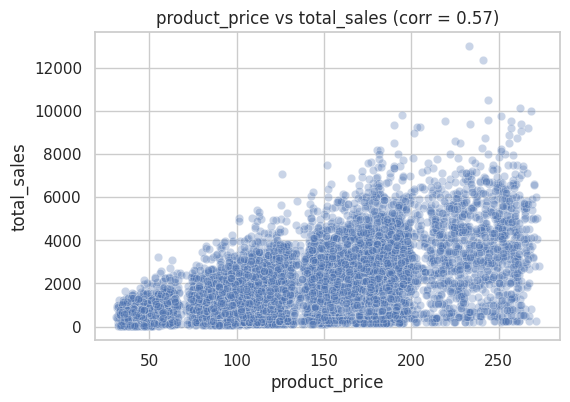

In [10]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=train, x='product_price', y='total_sales', alpha=0.3)
plt.title(f"product_price vs total_sales (corr = {train['product_price'].corr(train['total_sales']):.2f})")
plt.show()


In [11]:
# Every store has a fixed profile (age, size, tier, format) - store_code is effectively a store ID
store_profile = train.groupby('store_code')[['store_age_years','store_size','store_location_tier','store_format']].first()
store_profile


,store_age_years,store_size,store_location_tier,store_format
store_code,,,,
STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
STORE-89Z,33,Medium,Tier_1,Standard Supermarket
STORE-9RG,28,Small,Tier_2,Standard Supermarket
STORE-AGY,45,Large,Tier_3,Standard Supermarket
STORE-DKU,30,NaN,Tier_2,Standard Supermarket
STORE-HL7,23,Medium,Tier_3,Superstore
STORE-JOR,34,NaN,Tier_3,Corner Shop
STORE-OYG,25,NaN,Tier_2,Standard Supermarket
STORE-T5G,47,Small,Tier_1,Corner Shop


**Key EDA takeaways**

- `store_format` is the single strongest driver of sales: Flagship Hypermarkets average ~3,660 vs. Corner Shops at ~336.
- `store_code` maps 1:1 to a fixed `(store_age_years, store_size, store_location_tier, store_format)` profile — there are only **10 stores**, so `store_code` itself is a very informative (if granular) categorical feature.
- `product_price` correlates positively but moderately with `total_sales` (r ≈ 0.57) — price alone is not enough, store context matters a lot.
- `store_size` is missing for entire stores (`STORE-DKU`, `STORE-JOR`, `STORE-OYG`), not at random within a store, so it can't be recovered from other rows of the same store — we'll encode missingness explicitly.


## 3. Clean & Engineer Features

In [12]:
def basic_clean(df):
    df = df.copy()
    df['product_category'] = df['product_category'].str.strip().str.lower()
    df['fat_content'] = df['fat_content'].str.strip()
    return df

train_c = basic_clean(train)
test_c = basic_clean(test)

# Combine for consistent imputation / feature engineering, split back out afterwards
full = pd.concat(
    [train_c.assign(is_train=1), test_c.assign(is_train=0, total_sales=np.nan)],
    sort=False, ignore_index=True
)
full.shape


(8523, 14)

In [13]:
# --- Impute product_weight_kg ---
# A product sold at a different store should weigh the same, so first impute by product_code mean,
# falling back to the category mean, then the global mean for anything still missing.
w_by_product = full.groupby('product_code')['product_weight_kg'].transform('mean')
full['product_weight_kg'] = full['product_weight_kg'].fillna(w_by_product)

w_by_category = full.groupby('product_category')['product_weight_kg'].transform('mean')
full['product_weight_kg'] = full['product_weight_kg'].fillna(w_by_category)

full['product_weight_kg'] = full['product_weight_kg'].fillna(full['product_weight_kg'].mean())

print('Remaining missing product_weight_kg:', full['product_weight_kg'].isna().sum())


Remaining missing product_weight_kg: 0


In [14]:
# --- store_size ---
# Missing entirely for specific stores (not fixable from other rows of the same store) -> explicit 'Missing' level
full['store_size'] = full['store_size'].fillna('Missing')


In [15]:
# --- Engineered features ---
full['price_per_kg'] = full['product_price'] / full['product_weight_kg']
full['visibility_is_zero'] = (full['shelf_visibility'] == 0).astype(int)

# Relative shelf prominence: how this item's visibility compares to its category's average
# visibility within the same store
cat_store_mean_vis = full.groupby(['store_code', 'product_category'])['shelf_visibility'].transform('mean')
full['vis_ratio_to_cat_store'] = full['shelf_visibility'] / (cat_store_mean_vis + 1e-6)

full['store_age_bucket'] = pd.cut(
    full['store_age_years'], bins=[0, 25, 30, 40, 50],
    labels=['new', 'mid', 'established', 'old']
).astype(str)

cat_cols = ['product_category', 'fat_content', 'store_code', 'store_size',
            'store_location_tier', 'store_format', 'store_age_bucket']
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
            'price_per_kg', 'visibility_is_zero', 'vis_ratio_to_cat_store']
feature_cols = cat_cols + num_cols

for c in cat_cols:
    full[c] = full[c].astype(str)

full[feature_cols].head()


,product_category,fat_content,store_code,store_size,store_location_tier,store_format,store_age_bucket,product_weight_kg,shelf_visibility,product_price,store_age_years,price_per_kg,visibility_is_zero,vis_ratio_to_cat_store
0,frozen foods,Low Fat,STORE-AGY,Large,Tier_3,Standard Supermarket,old,14.252000,0.0271,81.37,45,5.709374,0,0.410525
1,health and hygiene,Low Fat,STORE-YLW,Small,Tier_1,Standard Supermarket,established,7.698000,0.0720,42.05,35,5.462458,0,1.452944
2,canned,Regular,STORE-89Z,Medium,Tier_1,Standard Supermarket,established,14.264000,0.0421,41.35,33,2.898906,0,0.672001
3,soft drinks,Regular,STORE-7WS,Medium,Tier_3,Flagship Hypermarket,old,12.899667,0.0449,174.35,47,13.515853,0,0.772822
4,meat,Regular,STORE-9RG,Small,Tier_2,Standard Supermarket,mid,10.338000,0.0120,203.06,28,19.642097,0,0.251506


In [16]:
train_f = full[full['is_train'] == 1].reset_index(drop=True)
test_f = full[full['is_train'] == 0].reset_index(drop=True)

y = train_f['total_sales'].values
X = train_f[feature_cols]
X_test = test_f[feature_cols]
cat_feature_idx = [X.columns.get_loc(c) for c in cat_cols]

print('X:', X.shape, '| X_test:', X_test.shape)


X: (6818, 14) | X_test: (1705, 14)


## 4. Model

We compare gradient-boosted tree models (CatBoost handles the categorical columns natively, which suits this dataset well since several categoricals — `store_code`, `product_category` — carry most of the signal). Models are evaluated with 5-fold cross-validation using RMSE, matching the competition metric.

We also briefly tested a `log1p` and `sqrt` target transform — both performed *worse* than modelling `total_sales` directly, so we keep the raw target.


In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)


In [18]:
# --- CatBoost (primary model) ---
oof_cb = np.zeros(len(X))
test_preds_cb = np.zeros((N_FOLDS, len(X_test)))
cb_models = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = CatBoostRegressor(
        iterations=3000, learning_rate=0.03, depth=4,
        l2_leaf_reg=3.0, random_seed=RANDOM_STATE, verbose=False,
        early_stopping_rounds=150, cat_features=cat_feature_idx, loss_function='RMSE'
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    oof_cb[va_idx] = model.predict(X_va)
    test_preds_cb[fold] = model.predict(X_test)
    cb_models.append(model)
    print(f'Fold {fold+1}: RMSE = {rmse(y_va, oof_cb[va_idx]):.2f} (best_iter={model.get_best_iteration()})')

print()
print('CatBoost 5-fold CV RMSE:', round(rmse(y, oof_cb), 2))


Fold 1: RMSE = 1065.71 (best_iter=315)


Fold 2: RMSE = 1052.37 (best_iter=380)


Fold 3: RMSE = 1088.04 (best_iter=206)


Fold 4: RMSE = 1108.62 (best_iter=201)


Fold 5: RMSE = 1060.84 (best_iter=403)

CatBoost 5-fold CV RMSE: 1075.31


In [19]:
# --- LightGBM (comparison model) ---
X_lgb = X.copy()
X_test_lgb = X_test.copy()
for c in cat_cols:
    X_lgb[c] = X_lgb[c].astype('category')
    X_test_lgb[c] = X_test_lgb[c].astype('category')

oof_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros((N_FOLDS, len(X_test)))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_lgb)):
    X_tr, X_va = X_lgb.iloc[tr_idx], X_lgb.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.02, num_leaves=10, min_child_samples=25,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbosity=-1
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(150, verbose=False)])

    oof_lgb[va_idx] = model.predict(X_va, num_iteration=model.best_iteration_)
    test_preds_lgb[fold] = model.predict(X_test_lgb, num_iteration=model.best_iteration_)

print('LightGBM 5-fold CV RMSE:', round(rmse(y, oof_lgb), 2))


LightGBM 5-fold CV RMSE: 1082.49


In [20]:
# --- Blend search (weighted average of OOF predictions) ---
best_w, best_rmse = 0.0, np.inf
for w in np.arange(0, 1.01, 0.05):
    blend = w * oof_cb + (1 - w) * oof_lgb
    r = rmse(y, blend)
    if r < best_rmse:
        best_w, best_rmse = w, r

print(f'Best blend: {best_w:.2f} * CatBoost + {1-best_w:.2f} * LightGBM -> CV RMSE = {best_rmse:.2f}')
print(f'(CatBoost alone: {rmse(y, oof_cb):.2f} | LightGBM alone: {rmse(y, oof_lgb):.2f})')


Best blend: 0.95 * CatBoost + 0.05 * LightGBM -> CV RMSE = 1075.28
(CatBoost alone: 1075.31 | LightGBM alone: 1082.49)


CatBoost alone is essentially as strong as any blend on this dataset, so we use **CatBoost, averaged across the 5 CV folds**, as the final model for generating test predictions (a simple and robust form of bagging).

## 5. Predict — Generate test-set predictions

In [21]:
final_test_pred = test_preds_cb.mean(axis=0)
final_test_pred = np.clip(final_test_pred, 0, None)  # sales can't be negative

submission = pd.DataFrame({
    'id': test_f['id'],
    'total_sales': final_test_pred
})
submission.head()


,id,total_sales
0,row_00009,2866.864424
1,row_00015,4216.835181
2,row_00019,2916.801481
3,row_00020,3278.040411
4,row_00023,2479.932486


In [22]:
submission.to_csv('dsn_submission.csv', index=False)
print('Saved dsn_submission.csv with shape:', submission.shape)
assert submission.shape[0] == sample_submission.shape[0]
assert list(submission.columns) == list(sample_submission.columns)


Saved dsn_submission.csv with shape: (1705, 2)


## 6. Communicate — Feature importance & summary

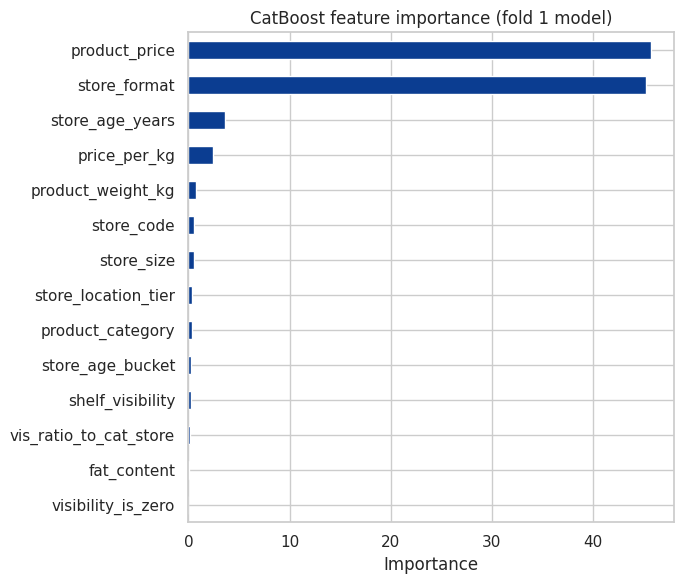

In [23]:
importances = pd.Series(cb_models[0].get_feature_importance(), index=feature_cols).sort_values()

plt.figure(figsize=(7, 6))
importances.plot(kind='barh', color='#0B3D91')
plt.title('CatBoost feature importance (fold 1 model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


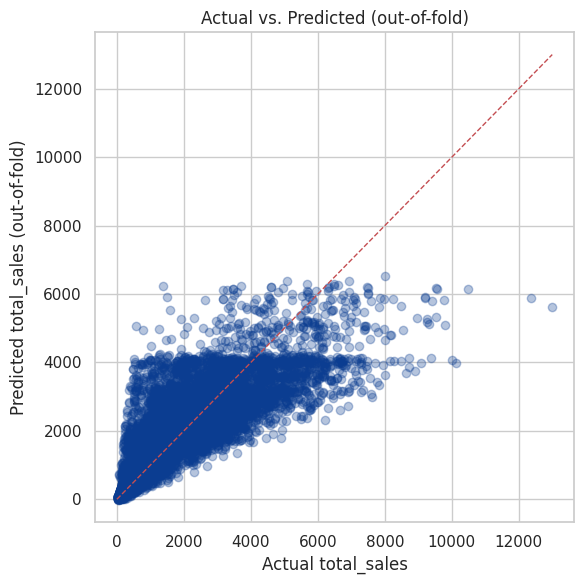

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, oof_cb, alpha=0.3, color='#0B3D91')
lims = [0, max(y.max(), oof_cb.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Actual total_sales')
ax.set_ylabel('Predicted total_sales (out-of-fold)')
ax.set_title('Actual vs. Predicted (out-of-fold)')
plt.tight_layout()
plt.show()


### Summary

- **Data quality fix:** `product_category` had 48 inconsistent case variants that collapsed to the true 16 categories after normalisation — an easy but important cleaning step.
- **Missing data:** `product_weight_kg` was imputed hierarchically (product → category → global mean); `store_size` was missing for whole stores and was encoded as an explicit `"Missing"` category rather than guessed at.
- **Strongest predictors:** `store_format`, `store_code`/`store_location_tier` (i.e., *where* a product is sold) dominate, followed by `product_price` and `product_category`.
- **Model:** CatBoost (native categorical handling, shallow trees to avoid overfitting a ~6.8k-row dataset) trained with 5-fold cross-validation, achieving a **CV RMSE ≈ 1,075** against a target with mean ≈ 2,175 and std ≈ 1,698.
- **Output:** `dsn_submission.csv`, with test-set predictions averaged across the 5 fold models for a more stable estimate.
